<a href="https://colab.research.google.com/github/Pro-phet123/Behavioral-Customer-Value-Prediction-Using-RFM-Analytics/blob/main/Customer_Value_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


### **ANALYSING THE DATASET**

In [ ]:
#Importing dependecies
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd
import numpy as np
import sqlite3
from datetime import datetime

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load and Clean Date Formats
df_raw = pd.read_csv("/content/drive/MyDrive/OnlineRetail.csv", encoding='cp1252')

# Show first 5 rows to verify structure
df_raw.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
# Dataset shape
df_raw.shape

(541909, 8)

In [ ]:
# Column names
df_raw.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [ ]:
# Data types
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
# Summary statistics
df_raw.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [ ]:
# Missing values
df_raw.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
print(f"Duplicate Rows: {df_raw.duplicated().sum()}")

Duplicate Rows: 5268


####**Dataset Overview**


* **Number of records:** 541,909
* **Number of columns:** 8
* **Duplicate rows:** 5,268
* **Missing CustomerID:** 135,080
* **Missing Description:** 1,454

####**Standardizing Date Format**

In [ ]:

# Standardize dates so SQLite JULIANDAY can parse them properly
df_raw['InvoiceDate'] = (pd.to_datetime(df_raw['InvoiceDate']).dt.strftime('%Y-%m-%d %H:%M:%S'))




######**The InvoiceDate column is converted to the ISO 8601 format (YYYY-MM-DD HH:MM:SS).**

######Although pandas handles datetime objects internally without any issues, storing the dates as ISO-formatted strings ensures that SQLite's built-in date and time functions **(e.g., JULIANDAY() and DATE()) parse and process them consistently.**

######This improves compatibility and avoids potential issues with how datetime values are written to and interpreted by SQLite.

### **IN-DATABASE DATA CLEANING & AGGREGATION (SQL)**

In [ ]:
# Creating the SQLite Database
import sqlite3

conn = sqlite3.connect("retail.db")

In [ ]:
# Converting dataframe to sql and saving the table

df_raw.to_sql(
    "transactions",
    conn,
    if_exists="replace",
    index=False
)

print("Database created successfully.")

Database created successfully.


In [ ]:
# Show first 5 rows to verify structure

query = """
SELECT *
FROM transactions
LIMIT 5;
"""

pd.read_sql_query(query, conn)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
# Total number of rows
query = """
SELECT COUNT(*) AS total_rows
FROM transactions;
"""

pd.read_sql_query(query, conn)

,total_rows
0,541909


In [ ]:
# Checking the Date Range

query = """
SELECT
MIN(InvoiceDate) AS Start_Date,
MAX(InvoiceDate) AS End_Date
FROM transactions;
"""

pd.read_sql_query(query, conn)

,Start_Date,End_Date
0,2010-12-01 08:26:00,2011-12-09 12:50:00


In [ ]:
# Creating a cleaned table

query = """
DROP TABLE IF EXISTS transactions_clean;

CREATE TABLE transactions_clean AS

SELECT DISTINCT
    InvoiceNo,
    StockCode,
    Description,
    Quantity,
    InvoiceDate,
    UnitPrice,
    CustomerID,
    Country

FROM transactions

WHERE CustomerID IS NOT NULL
  AND InvoiceNo NOT LIKE 'C%'
  AND Quantity > 0
  AND UnitPrice > 0;
"""

conn.executescript(query)

print("transactions_clean created successfully.")

transactions_clean created successfully.


##### **SQL Data Cleaning**

The raw dataset is preserved in the `transactions` table. A new table, `transactions_clean`, is created to store cleaned records. This approach preserves the original data for auditing and reproducibility while providing a clean dataset for feature engineering and machine learning.

In [ ]:
# Show first 5 rows to verify structure

pd.read_sql_query("""
SELECT *
FROM transactions_clean
LIMIT 5;
""", conn)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
# Total number of rows after cleaning
pd.read_sql_query("""
SELECT COUNT(*) AS Cleaned_Rows
FROM transactions_clean;
""", conn)

,Cleaned_Rows
0,392692


In [ ]:
# Checking missing values after cleaning

pd.read_sql_query("""
SELECT
SUM(CASE WHEN CustomerID IS NULL THEN 1 ELSE 0 END) AS Missing_CustomerID,
SUM(CASE WHEN Quantity <= 0 THEN 1 ELSE 0 END) AS Invalid_Quantity,
SUM(CASE WHEN UnitPrice <= 0 THEN 1 ELSE 0 END) AS Invalid_UnitPrice
FROM transactions_clean;
""", conn)

,Missing_CustomerID,Invalid_Quantity,Invalid_UnitPrice
0,0,0,0


In [ ]:
# Checking cancelled invoice after cleaning

pd.read_sql_query("""
SELECT COUNT(*) AS Cancelled_Invoices
FROM transactions_clean
WHERE InvoiceNo LIKE 'C%';
""", conn)

,Cancelled_Invoices
0,0


In [ ]:
# checking duplicates after cleaning

pd.read_sql_query("""
SELECT COUNT(*) AS Duplicate_Rows
FROM (
    SELECT *,
           COUNT(*) AS cnt
    FROM transactions_clean
    GROUP BY
        InvoiceNo,
        StockCode,
        Description,
        Quantity,
        InvoiceDate,
        UnitPrice,
        CustomerID,
        Country
    HAVING cnt > 1
);
""", conn)

,Duplicate_Rows
0,0


##### **Time-Based Split (Prevent Data Leakage)**

In [ ]:
# Checking the Date Range

pd.read_sql_query("""
SELECT
MIN(InvoiceDate) AS Start_Date,
MAX(InvoiceDate) AS End_Date
FROM transactions_clean;
""", conn)

,Start_Date,End_Date
0,2010-12-01 08:26:00,2011-12-09 12:50:00


In [ ]:
# Checking the last date of the entire transactions

last_date = pd.read_sql_query("""
SELECT MAX(InvoiceDate) AS Last_Date
FROM transactions_clean;
""", conn)

last_date

,Last_Date
0,2011-12-09 12:50:00


In [ ]:
# Dividing the dataset using date (First 10 months)

query = """
DROP TABLE IF EXISTS historical_transactions;

CREATE TABLE historical_transactions AS

SELECT *
FROM transactions_clean

WHERE InvoiceDate < '2011-10-01';
"""

conn.executescript(query)

In [ ]:
# Dividing the dataset using date (Remaining 2 months)


query = """
DROP TABLE IF EXISTS future_transactions;

CREATE TABLE future_transactions AS

SELECT *
FROM transactions_clean

WHERE InvoiceDate >= '2011-10-01';
"""

conn.executescript(query)

In [ ]:
# Verifying  the table for the first 10 months

pd.read_sql_query("""
SELECT COUNT(*) AS Historical_Transactions
FROM historical_transactions;
""", conn)

,Historical_Transactions
0,263705


In [ ]:
# Verifying  the table for the last 2 months

pd.read_sql_query("""
SELECT COUNT(*) AS Future_Transactions
FROM future_transactions;
""", conn)

,Future_Transactions
0,128987


##### **Feature Engineering**

In [ ]:
# Checking the last date of the historical_transactions

pd.read_sql_query("""
SELECT
MAX(InvoiceDate) AS Reference_Date
FROM historical_transactions;
""", conn)

,Reference_Date
0,2011-09-30 15:52:00


In [ ]:
# Creating the Customer Features Table for prediction

query = """
DROP TABLE IF EXISTS customer_features;

CREATE TABLE customer_features AS

SELECT

CustomerID,

Country,

ROUND(
JULIANDAY('2011-09-30') -
JULIANDAY(MAX(InvoiceDate))
) AS Recency,

COUNT(DISTINCT InvoiceNo) AS Frequency,

ROUND(AVG(UnitPrice * Quantity),2) AS Average_Order_Value,

ROUND(AVG(Quantity),2) AS Average_Quantity,

SUM(Quantity) AS Total_Items,

COUNT(DISTINCT StockCode) AS Unique_Products,

COUNT(*) AS Number_of_Transactions

FROM historical_transactions

GROUP BY CustomerID;
"""

conn.executescript(query)

print("Customer feature table created successfully.")

Customer feature table created successfully.


In [ ]:
# View the Engineered Dataset

pd.read_sql_query("""
SELECT *
FROM customer_features
LIMIT 10;
""", conn)

,CustomerID,Country,Recency,Frequency,Average_Order_Value,Average_Quantity,Total_Items,Unique_Products,Number_of_Transactions
0,12346.0,United Kingdom,255.0,1,77183.60,74215.00,74215,1,1
1,12347.0,Iceland,59.0,5,22.51,12.82,1590,82,124
2,12348.0,Finland,4.0,4,57.98,75.52,2341,22,31
3,12350.0,Norway,239.0,1,19.67,11.59,197,17,17
4,12352.0,Norway,1.0,7,31.35,5.84,409,47,70
5,12353.0,Bahrain,133.0,1,22.25,5.00,20,4,4
6,12354.0,Spain,161.0,1,18.61,9.14,530,58,58
7,12355.0,Bahrain,143.0,1,35.34,18.46,240,13,13
8,12356.0,Portugal,174.0,2,48.30,27.82,1586,53,57
9,12358.0,Austria,80.0,1,40.41,8.33,100,12,12


In [ ]:
# Check Missing Values of the Engineered Dataset

pd.read_sql_query("""
SELECT

SUM(CASE WHEN Recency IS NULL THEN 1 ELSE 0 END) AS Missing_Recency,

SUM(CASE WHEN Frequency IS NULL THEN 1 ELSE 0 END) AS Missing_Frequency,

SUM(CASE WHEN Average_Order_Value IS NULL THEN 1 ELSE 0 END) AS Missing_AOV,

SUM(CASE WHEN Average_Quantity IS NULL THEN 1 ELSE 0 END) AS Missing_Average_Quantity,

SUM(CASE WHEN Total_Items IS NULL THEN 1 ELSE 0 END) AS Missing_Total_Items,

SUM(CASE WHEN Unique_Products IS NULL THEN 1 ELSE 0 END) AS Missing_Unique_Products,

SUM(CASE WHEN Number_of_Transactions IS NULL THEN 1 ELSE 0 END) AS Missing_Transactions

FROM customer_features;
""", conn)

,Missing_Recency,Missing_Frequency,Missing_AOV,Missing_Average_Quantity,Missing_Total_Items,Missing_Unique_Products,Missing_Transactions
0,0,0,0,0,0,0,0


In [ ]:
# Creating the Future customer spending table.


query = """
DROP TABLE IF EXISTS future_customer_spending;

CREATE TABLE future_customer_spending AS

SELECT

CustomerID,

ROUND(SUM(UnitPrice * Quantity),2) AS Future_Spending

FROM future_transactions

GROUP BY CustomerID;
"""

conn.executescript(query)

print("Future customer spending table created successfully.")

Future customer spending table created successfully.


In [ ]:
# View the Future customer spending table.


pd.read_sql_query("""
SELECT *
FROM future_customer_spending
ORDER BY Future_Spending DESC
LIMIT 10;
""", conn)

,CustomerID,Future_Spending
0,16446.0,168469.60
1,18102.0,79497.89
2,14646.0,77099.38
3,14096.0,55878.09
4,14911.0,48076.04
5,17450.0,33367.81
6,16684.0,32770.06
7,17511.0,26656.99
8,16029.0,25465.10
9,14088.0,24983.92


In [ ]:
# Getting the median future spenders (i.e spenders of the last 2 months)

future_spending = pd.read_sql_query("""
SELECT Future_Spending
FROM future_customer_spending
ORDER BY Future_Spending;
""", conn)

median_spending = future_spending["Future_Spending"].median()

print("Median Future Spending:", median_spending)

Median Future Spending: 439.61


The `median future_spending` will help to divide the customer's into high value and low value customers. Since the median is know `439.61` a threshold can be created.

##### **Creating Target variable (Y) for prediction**

In [ ]:
median_value = median_spending

query = f"""
DROP TABLE IF EXISTS customer_target;

CREATE TABLE customer_target AS

SELECT

CustomerID,

Future_Spending,

CASE

WHEN Future_Spending > {median_value}

THEN 1

ELSE 0

END AS Target

FROM future_customer_spending;
"""

conn.executescript(query)

print("Target variable created successfully.")

Target variable created successfully.


In [ ]:
# View the target dataset.


pd.read_sql_query("""
SELECT *
FROM customer_target
LIMIT 10;
""", conn)

,CustomerID,Future_Spending,Target
0,12347.0,1519.14,1
1,12349.0,1757.55,1
2,12352.0,311.73,0
3,12356.0,58.35,0
4,12357.0,6207.67,1
5,12358.0,683.20,1
6,12359.0,2814.30,1
7,12360.0,1043.78,1
8,12362.0,2648.89,1
9,12364.0,609.38,1


In [ ]:
# Checking the target class if dataset is balanced

pd.read_sql_query("""
SELECT

Target,

COUNT(*) AS Customers

FROM customer_target

GROUP BY Target;
""", conn)

,Target,Customers
0,0,1280
1,1,1280


#### **Insight**

The target classes are evenly balanced, with approximately 50% of customers in each class. This balanced distribution is beneficial for model training because it reduces prediction bias toward one class and eliminates the need for class-balancing techniques such as SMOTE.

In [ ]:
# Merging the features with the target variable to create the full dataset before splitting

query = """
DROP TABLE IF EXISTS customer_model;

CREATE TABLE customer_model AS

SELECT

cf.CustomerID,

cf.Country,

cf.Recency,

cf.Frequency,

cf.Average_Order_Value,

cf.Average_Quantity,

cf.Total_Items,

cf.Unique_Products,

cf.Number_of_Transactions,

COALESCE(ct.Future_Spending,0) AS Future_Spending,

COALESCE(ct.Target,0) AS Target

FROM customer_features cf

LEFT JOIN customer_target ct

ON cf.CustomerID = ct.CustomerID;
"""

conn.executescript(query)

print("Final modelling dataset created successfully.")

Final modelling dataset created successfully.


In [ ]:
# View the Final modelling dataset .

pd.read_sql_query("""
SELECT *
FROM customer_model
LIMIT 10;
""", conn)

,CustomerID,Country,Recency,Frequency,Average_Order_Value,Average_Quantity,Total_Items,Unique_Products,Number_of_Transactions,Future_Spending,Target
0,12346.0,United Kingdom,255.0,1,77183.60,74215.00,74215,1,1,0.00,0
1,12347.0,Iceland,59.0,5,22.51,12.82,1590,82,124,1519.14,1
2,12348.0,Finland,4.0,4,57.98,75.52,2341,22,31,0.00,0
3,12350.0,Norway,239.0,1,19.67,11.59,197,17,17,0.00,0
4,12352.0,Norway,1.0,7,31.35,5.84,409,47,70,311.73,0
5,12353.0,Bahrain,133.0,1,22.25,5.00,20,4,4,0.00,0
6,12354.0,Spain,161.0,1,18.61,9.14,530,58,58,0.00,0
7,12355.0,Bahrain,143.0,1,35.34,18.46,240,13,13,0.00,0
8,12356.0,Portugal,174.0,2,48.30,27.82,1586,53,57,58.35,0
9,12358.0,Austria,80.0,1,40.41,8.33,100,12,12,683.20,1


In [ ]:
# Load the SQL table into Pandas

customer_df = pd.read_sql_query("""
SELECT *
FROM customer_model;
""", conn)

customer_df.head()

,CustomerID,Country,Recency,Frequency,Average_Order_Value,Average_Quantity,Total_Items,Unique_Products,Number_of_Transactions,Future_Spending,Target
0,12346.0,United Kingdom,255.0,1,77183.60,74215.00,74215,1,1,0.00,0
1,12347.0,Iceland,59.0,5,22.51,12.82,1590,82,124,1519.14,1
2,12348.0,Finland,4.0,4,57.98,75.52,2341,22,31,0.00,0
3,12350.0,Norway,239.0,1,19.67,11.59,197,17,17,0.00,0
4,12352.0,Norway,1.0,7,31.35,5.84,409,47,70,311.73,0


##### **Loading the Modelling Dataset into Python**

The customer-level modelling dataset is loaded from SQLite into a Pandas DataFrame for exploratory data analysis and machine learning.

In [ ]:
# Dataset shape
customer_df.shape

(3616, 11)

In [ ]:
# Final Dataset dtype.
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3616 entries, 0 to 3615
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              3616 non-null   float64
 1   Country                 3616 non-null   object 
 2   Recency                 3616 non-null   float64
 3   Frequency               3616 non-null   int64  
 4   Average_Order_Value     3616 non-null   float64
 5   Average_Quantity        3616 non-null   float64
 6   Total_Items             3616 non-null   int64  
 7   Unique_Products         3616 non-null   int64  
 8   Number_of_Transactions  3616 non-null   int64  
 9   Future_Spending         3616 non-null   float64
 10  Target                  3616 non-null   int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 310.9+ KB


In [ ]:
# Final Dataset Summary Statistics.

customer_df.describe()

,CustomerID,Recency,Frequency,Average_Order_Value,Average_Quantity,Total_Items,Unique_Products,Number_of_Transactions,Future_Spending,Target
count,3616.000000,3616.000000,3616.000000,3616.000000,3616.000000,3616.000000,3616.000000,3616.000000,3616.000000,3616.000000
mean,15276.650166,91.243363,3.641593,60.015708,42.895265,997.720962,52.224281,72.927268,637.719718,0.283462
std,1722.620797,86.842443,6.121759,1307.412996,1239.003185,4083.134728,72.241448,158.315432,3917.477770,0.450741
min,12346.000000,-1.000000,1.000000,1.450000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,13780.750000,17.000000,1.000000,12.950000,6.050000,139.000000,14.000000,15.000000,0.000000,0.000000
50%,15250.000000,63.000000,2.000000,17.830000,9.900000,331.000000,30.500000,34.000000,69.055000,0.000000
75%,16755.250000,147.000000,4.000000,25.500000,14.700000,825.000000,65.000000,80.000000,518.595000,1.000000
max,18287.000000,303.000000,139.000000,77183.600000,74215.000000,143895.000000,1474.000000,4919.000000,168469.600000,1.000000


In [ ]:
# Final Dataset Missing.
customer_df.isnull().sum()

,0
CustomerID,0
Country,0
Recency,0
Frequency,0
Average_Order_Value,0
...,...
Total_Items,0
Unique_Products,0
Number_of_Transactions,0
Future_Spending,0


### **EXPLORATORY DATA ANALYSIS**

##### **Exploratory Data Analysis (EDA)**

The purpose of this analysis is to understand the characteristics of the engineered customer features, identify potential outliers, examine feature distributions, and explore relationships that may influence customer value prediction.

In [ ]:
# Target distribution
customer_df["Target"].value_counts()

,count
Target,
0,2591
1,1025


#### **Insight**

The intermediate target table is balanced because the median spending threshold divides future purchasers into two equal groups.

However, after merging with all historical customers, the final modelling dataset becomes moderately imbalanced (71.65% vs. 28.35%), since customers with no future purchases are correctly assigned to the low-value class (Target = 0).

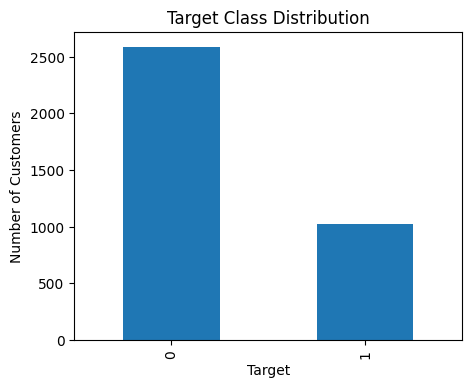

In [ ]:
# Target distribution plot

plt.figure(figsize=(5,4))

customer_df["Target"].value_counts().plot(
    kind="bar"
)

plt.title("Target Class Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Customers")

plt.show()

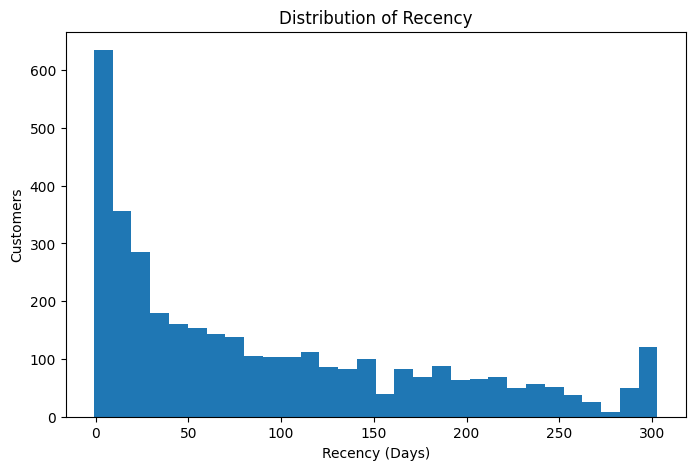

In [ ]:
# Recency Distribution plot
plt.figure(figsize=(8,5))

plt.hist(customer_df["Recency"], bins=30)

plt.title("Distribution of Recency")
plt.xlabel("Recency (Days)")
plt.ylabel("Customers")

plt.show()

#### **Insight**

Most customers purchased relatively recently `(median = 63 days)`, but the right-skewed distribution shows a smaller group of inactive customers who have not purchased for several months.

Lower recency appears to be associated with stronger customer engagement.

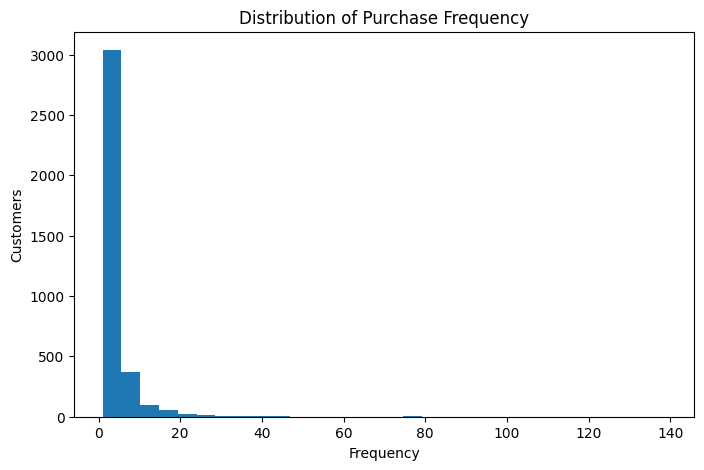

In [ ]:
# Frequency Distribution plot

plt.figure(figsize=(8,5))

plt.hist(customer_df["Frequency"], bins=30)

plt.title("Distribution of Purchase Frequency")
plt.xlabel("Frequency")
plt.ylabel("Customers")

plt.show()

#### **Insight**

Most customers made only one or two purchases, while a small group purchased very frequently.

This highlights a typical retail pattern where loyal customers account for a large share of purchasing activity.

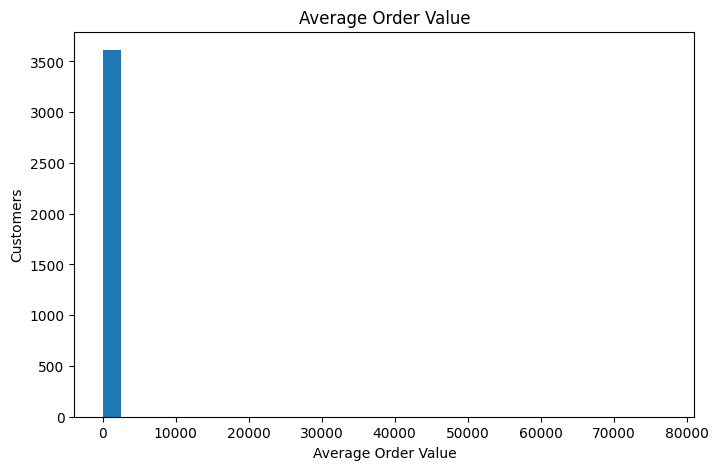

In [ ]:
# Average Order Value Distribution plot.

plt.figure(figsize=(8,5))

plt.hist(customer_df["Average_Order_Value"], bins=30)

plt.title("Average Order Value")
plt.xlabel("Average Order Value")
plt.ylabel("Customers")

plt.show()

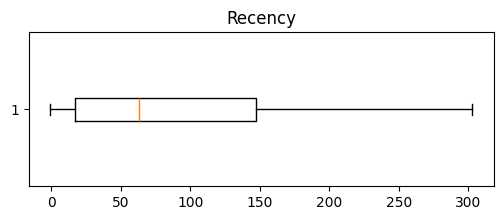

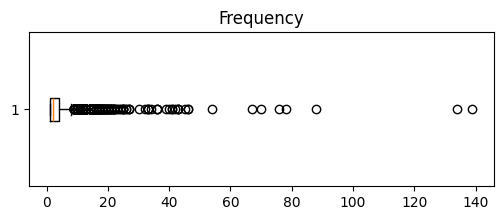

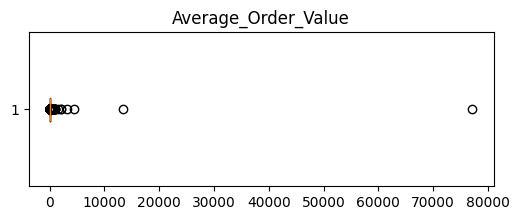

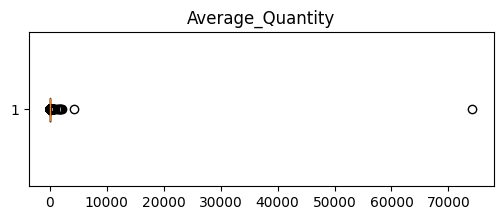

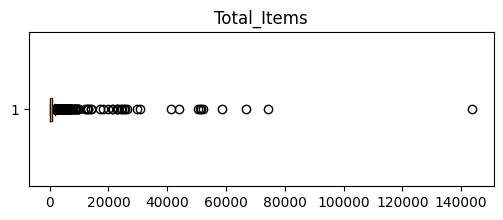

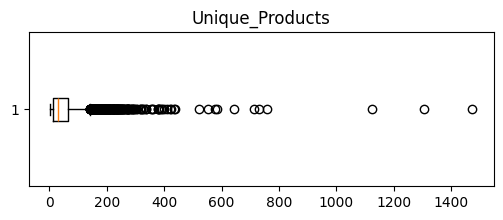

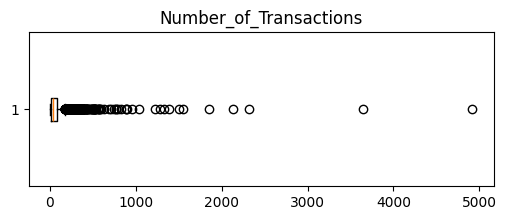

In [ ]:
# Boxplots for Outlier Detection plot

numerical_columns = [
    "Recency",
    "Frequency",
    "Average_Order_Value",
    "Average_Quantity",
    "Total_Items",
    "Unique_Products",
    "Number_of_Transactions"
]

for column in numerical_columns:

    plt.figure(figsize=(6,2))

    plt.boxplot(customer_df[column], vert=False)

    plt.title(column)

    plt.show()

#### **Insight**

Outliers were mainly found in purchasing-related features and are likely genuine high-value customers rather than data errors. These customers represent important business opportunities and should be retained in the analysis.

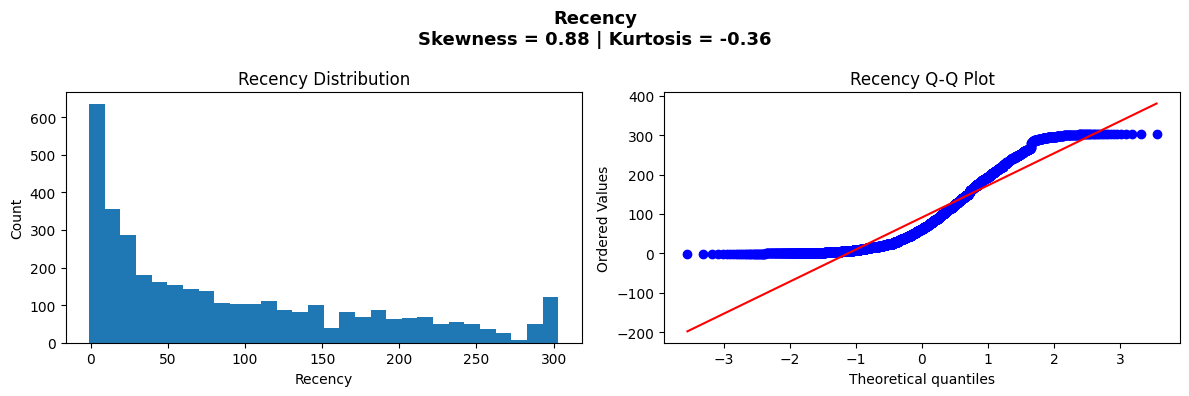

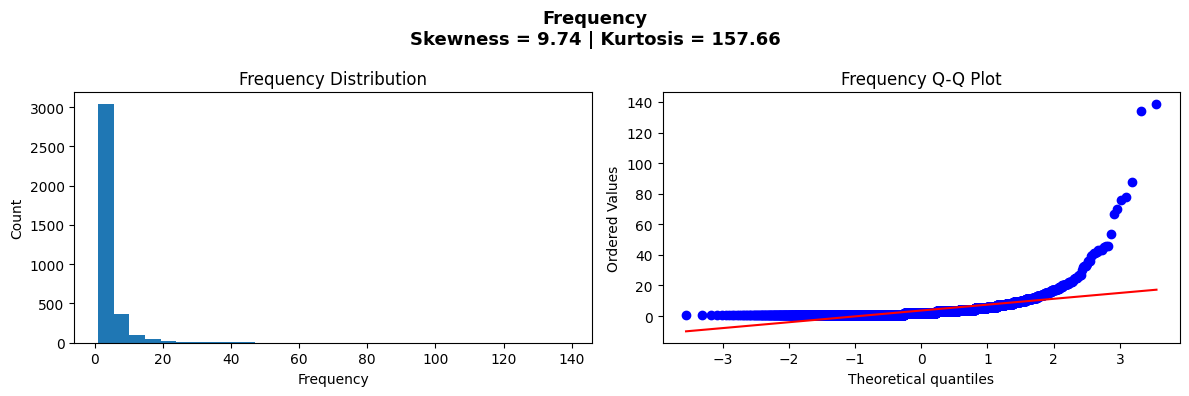

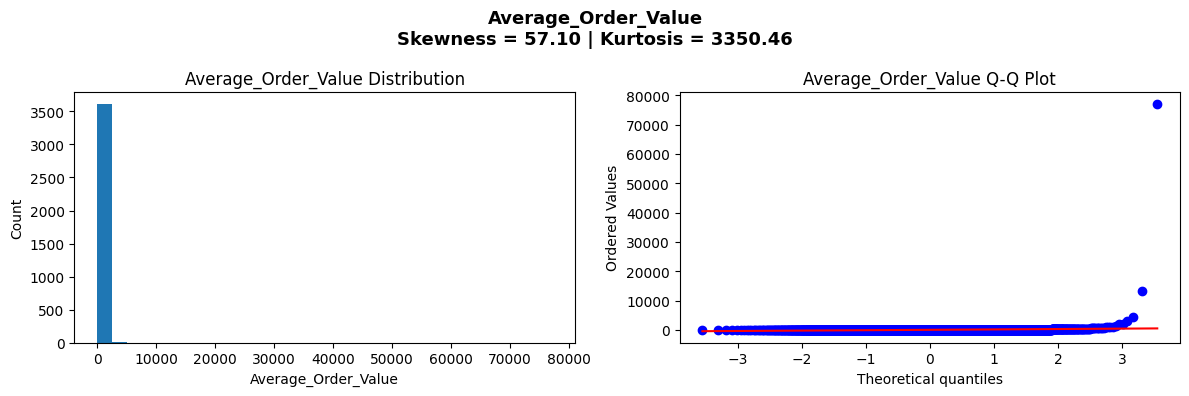

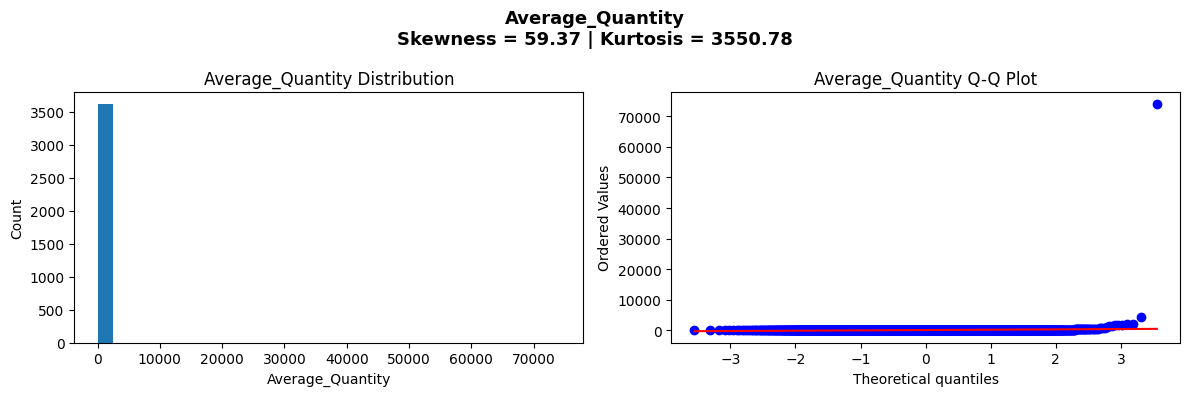

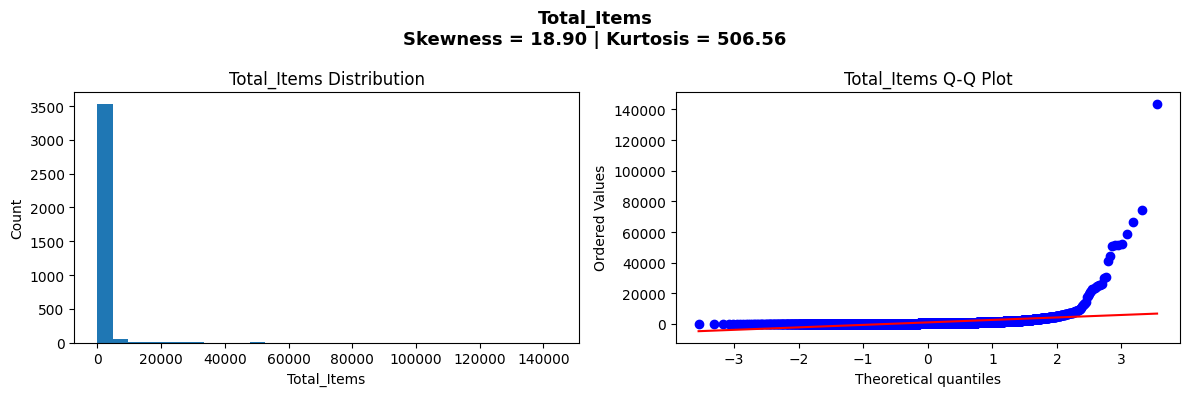

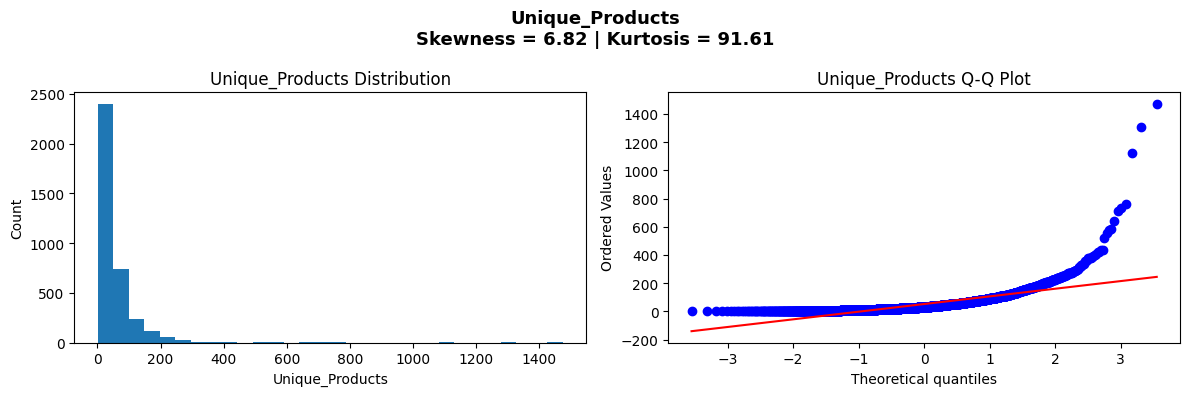

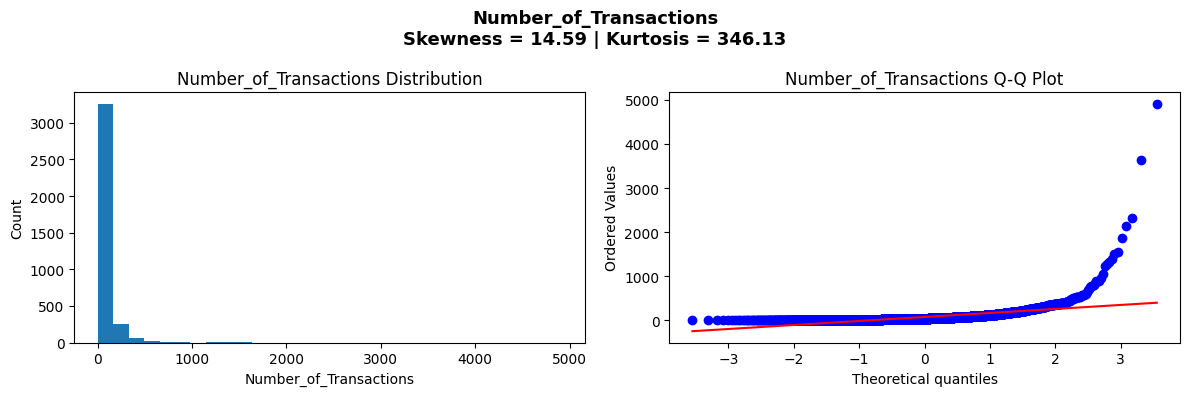

In [ ]:
# Skewness & Kurtosis

from scipy.stats import skew, kurtosis, probplot

# Numerical columns
numerical_columns = [
    "Recency",
    "Frequency",
    "Average_Order_Value",
    "Average_Quantity",
    "Total_Items",
    "Unique_Products",
    "Number_of_Transactions"
]

for column in numerical_columns:

    # Calculate skewness and kurtosis
    skewness = skew(customer_df[column])
    kurt = kurtosis(customer_df[column])

    # Create plots
    fig, axes = plt.subplots(1, 2, figsize=(12,4))

    # Histogram
    axes[0].hist(customer_df[column], bins=30)
    axes[0].set_title(f"{column} Distribution")
    axes[0].set_xlabel(column)
    axes[0].set_ylabel("Count")

    # Q-Q Plot
    probplot(customer_df[column], dist="norm", plot=axes[1])
    axes[1].set_title(f"{column} Q-Q Plot")

    plt.suptitle(
        f"{column}\nSkewness = {skewness:.2f} | Kurtosis = {kurt:.2f}",
        fontsize=13,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

#### **Insight**

Most purchasing features are highly right-skewed with large kurtosis values, showing that a small number of customers purchase much more than the majority.

This suggests the presence of valuable customer segments that contribute disproportionately to overall sales.

In [ ]:
# Correlation Analysis

corr = customer_df.drop(columns=["CustomerID"]).corr(numeric_only=True)

corr

,Recency,Frequency,Average_Order_Value,Average_Quantity,Total_Items,Unique_Products,Number_of_Transactions,Future_Spending,Target
Recency,1.000000,-0.288253,0.032182,0.030710,-0.137212,-0.286383,-0.230206,-0.085587,-0.287141
Frequency,-0.288253,1.000000,-0.003356,-0.005419,0.530337,0.696786,0.778093,0.351943,0.356328
Average_Order_Value,0.032182,-0.003356,1.000000,0.983415,0.307628,-0.021455,-0.012894,0.004071,-0.012110
Average_Quantity,0.030710,-0.005419,0.983415,1.000000,0.309178,-0.017717,-0.010864,0.000239,-0.011329
Total_Items,-0.137212,0.530337,0.307628,0.309178,1.000000,0.415650,0.451988,0.499938,0.203470
Unique_Products,-0.286383,0.696786,-0.021455,-0.017717,0.415650,1.000000,0.906814,0.270875,0.364746
Number_of_Transactions,-0.230206,0.778093,-0.012894,-0.010864,0.451988,0.906814,1.000000,0.301934,0.311542
Future_Spending,-0.085587,0.351943,0.004071,0.000239,0.499938,0.270875,0.301934,1.000000,0.227428
Target,-0.287141,0.356328,-0.012110,-0.011329,0.203470,0.364746,0.311542,0.227428,1.000000


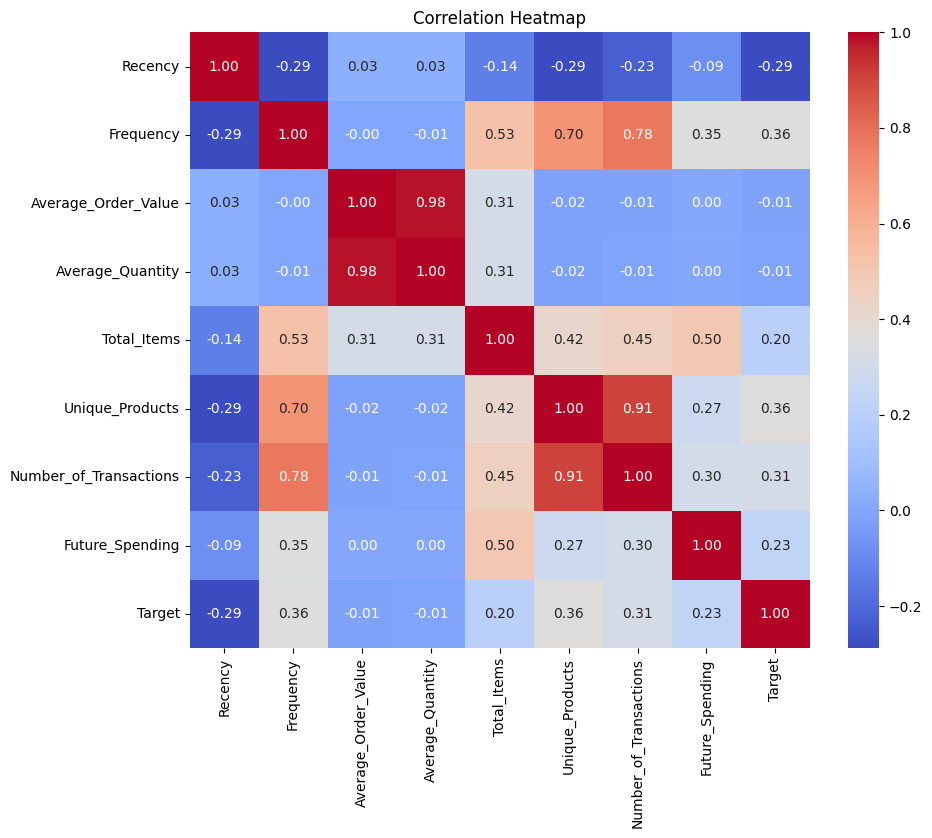

In [ ]:
# Correlation Heatmap plot

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

#### **Insight**

Unique products, purchase frequency, and number of transactions show the strongest positive relationship with the target class, while recency has a negative relationship.

This suggests customer engagement is a key indicator of becoming a future high-value customer.

In [ ]:
# Relationship Between Features and Target

customer_df.groupby("Target").mean(numeric_only=True)

,CustomerID,Recency,Frequency,Average_Order_Value,Average_Quantity,Total_Items,Unique_Products,Number_of_Transactions,Future_Spending
Target,,,,,,,,,
0,15319.893477,106.925125,2.269780,69.972262,51.723010,475.249325,35.653416,41.909687,77.421772
1,15167.339512,51.602927,7.109268,34.847483,20.580449,2318.427317,94.112195,151.333659,2054.043600


#### **Insight**

Customers who became high-value customers came back to buy more often, bought more different products, and made more purchases.

This suggests that buying regularly is the strongest indicator of future customer value.

In [ ]:
# Country Distribution
customer_df["Country"].value_counts().head(10)

,count
Country,
United Kingdom,3265
Germany,78
France,75
Belgium,24
Spain,23
Portugal,15
Switzerland,15
Norway,9
Channel Islands,9


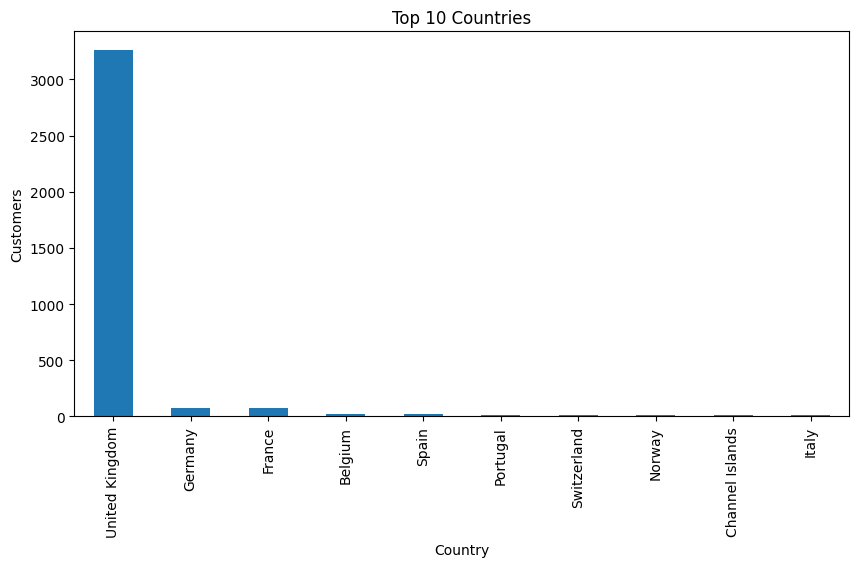

In [ ]:
# Top 10 Countries

customer_df["Country"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Customers")

plt.show()

#### **Insight**

The customer base is heavily concentrated in the United Kingdom (90.29%), meaning the model primarily captures purchasing behaviour from this market.

Business strategies are therefore likely to have the greatest impact within the UK.

### **MACHINE LEARNING MODEL DEVELOPMENT**

In [ ]:
# Features and Target

X = customer_df.drop(columns=[
    "CustomerID",
    "Country",
    "Future_Spending",
    "Target"
])

y = customer_df["Target"]

print(X.shape)
print(y.shape)

X.head()

(3616, 7)
(3616,)


,Recency,Frequency,Average_Order_Value,Average_Quantity,Total_Items,Unique_Products,Number_of_Transactions
0,255.0,1,77183.60,74215.00,74215,1,1
1,59.0,5,22.51,12.82,1590,82,124
2,4.0,4,57.98,75.52,2341,22,31
3,239.0,1,19.67,11.59,197,17,17
4,1.0,7,31.35,5.84,409,47,70


In [ ]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples :", X_test.shape)

Training samples: (2892, 7)
Testing samples : (724, 7)


In [ ]:
# Feature Scaling (*Requirement for LogisticsRegression)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

#### **Building the Baseline Model ( Using Logistic Regression)**

In [ ]:

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=42)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

#### **Baseline Model Evaluation (Logistics Regression)**

In [ ]:
# Definig y_pred to make Predictions and for evaluation

y_pred = log_model.predict(X_test_scaled)

y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

acc_log = accuracy_score(y_test, y_pred)
prec_log = precision_score(y_test, y_pred)
rec_log = recall_score(y_test, y_pred)
f1_log = f1_score(y_test, y_pred)

print("Accuracy :", acc_log)
print("Precision:", prec_log)
print("Recall   :", rec_log)
print("F1 Score :", f1_log)

Accuracy : 0.787292817679558
Precision: 0.7297297297297297
Recall   : 0.3951219512195122
F1 Score : 0.5126582278481012


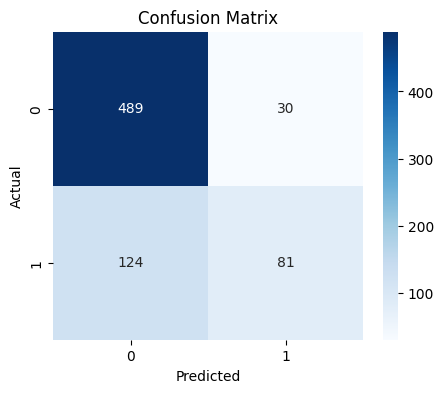

In [ ]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
# Classification Report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.94      0.86       519
           1       0.73      0.40      0.51       205

    accuracy                           0.79       724
   macro avg       0.76      0.67      0.69       724
weighted avg       0.78      0.79      0.76       724



#### **Baseline Model Evaluation (Decision Tree)**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Decision Tree Baseline")
print("Accuracy :", acc_dt)
print("Precision:", prec_dt)
print("Recall   :", rec_dt)
print("F1 Score :", f1_dt)

Decision Tree Baseline
Accuracy : 0.6906077348066298
Precision: 0.45454545454545453
Recall   : 0.4634146341463415
F1 Score : 0.45893719806763283


In [ ]:
# Classification Report of Baseline Model

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.79      0.78      0.78       519
           1       0.45      0.46      0.46       205

    accuracy                           0.69       724
   macro avg       0.62      0.62      0.62       724
weighted avg       0.69      0.69      0.69       724



#### **Baseline Model Evaluation (Random Forest)**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Baseline")
print("Accuracy :", acc_rf)
print("Precision:", prec_rf)
print("Recall   :", rec_rf)
print("F1 Score :", f1_rf)

Random Forest Baseline
Accuracy : 0.787292817679558
Precision: 0.6758620689655173
Recall   : 0.47804878048780486
F1 Score : 0.56


In [ ]:
# Classification Report of Baseline Model

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86       519
           1       0.68      0.48      0.56       205

    accuracy                           0.79       724
   macro avg       0.75      0.69      0.71       724
weighted avg       0.78      0.79      0.77       724



#### **Baseline Model Evaluation (XGBoost)**

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print("XGBoost Baseline")
print("Accuracy :", acc_xgb)
print("Precision:", prec_xgb)
print("Recall   :", rec_xgb)
print("F1 Score :", f1_xgb)

XGBoost Baseline
Accuracy : 0.7734806629834254
Precision: 0.6242424242424243
Recall   : 0.5024390243902439
F1 Score : 0.5567567567567567


In [ ]:
# Classification Report of Baseline Model

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       519
           1       0.62      0.50      0.56       205

    accuracy                           0.77       724
   macro avg       0.72      0.69      0.70       724
weighted avg       0.76      0.77      0.77       724



#### **Model Optimisation**

##### **Applying SMOTE (Training Data Only)**

In [ ]:
# Oversampling The training Data with SMOTE

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE
Target
0    2072
1     820
Name: count, dtype: int64

After SMOTE
Target
0    2072
1    2072
Name: count, dtype: int64


In [ ]:
# Training with the SMOTE Optimized training set.

from sklearn.linear_model import LogisticRegression

smote_model = LogisticRegression(random_state=42)

smote_model.fit(X_train_smote, y_train_smote)

LogisticRegression(random_state=42)

##### **Evaluting the SMOTE optimized Dataset (Logistics Regression)**

In [ ]:

# Evaluating the SMOTE Optimized Model

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

y_pred_smote = smote_model.predict(X_test_scaled)
y_prob_smote = smote_model.predict_proba(X_test_scaled)[:, 1]

acc_log_smote = accuracy_score(y_test, y_pred_smote)
prec_log_smote = precision_score(y_test, y_pred_smote)
rec_log_smote = recall_score(y_test, y_pred_smote)
f1_log_smote = f1_score(y_test, y_pred_smote)

print("Accuracy :", acc_log_smote)
print("Precision:", prec_log_smote)
print("Recall   :", rec_log_smote)
print("F1 Score :", f1_log_smote)

Accuracy : 0.7651933701657458
Precision: 0.579185520361991
Recall   : 0.624390243902439
F1 Score : 0.6009389671361502


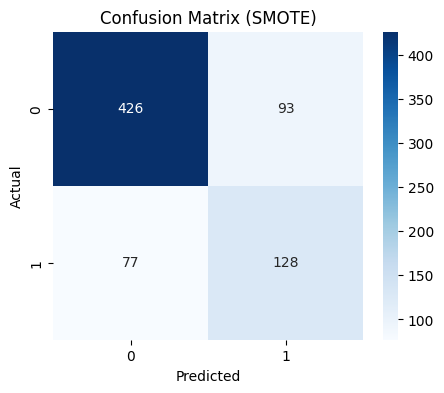

In [ ]:
# Confusion Matrix  Of the SMOTE optimized Model

cm = confusion_matrix(y_test, y_pred_smote)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (SMOTE)")
plt.show()

In [ ]:
# Classification Report of SMOTE optimized Modelling

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.85      0.82      0.83       519
           1       0.58      0.62      0.60       205

    accuracy                           0.77       724
   macro avg       0.71      0.72      0.72       724
weighted avg       0.77      0.77      0.77       724



##### **Evaluting the SMOTE optimized Dataset (Decision Tree)**

In [ ]:
dt_smote = DecisionTreeClassifier(random_state=42)

dt_smote.fit(X_train_smote, y_train_smote)

y_pred_dt_smote = dt_smote.predict(X_test_scaled)

acc_dt_smote = accuracy_score(y_test, y_pred_dt_smote)
prec_dt_smote = precision_score(y_test, y_pred_dt_smote)
rec_dt_smote = recall_score(y_test, y_pred_dt_smote)
f1_dt_smote = f1_score(y_test, y_pred_dt_smote)

print("Decision Tree + SMOTE")
print("Accuracy :", acc_dt_smote)
print("Precision:", prec_dt_smote)
print("Recall   :", rec_dt_smote)
print("F1 Score :", f1_dt_smote)

Decision Tree + SMOTE
Accuracy : 0.680939226519337
Precision: 0.4434782608695652
Recall   : 0.4975609756097561
F1 Score : 0.4689655172413793


In [ ]:
# Classification Report of SMOTE optimized Modelling

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt_smote))

              precision    recall  f1-score   support

           0       0.79      0.75      0.77       519
           1       0.44      0.50      0.47       205

    accuracy                           0.68       724
   macro avg       0.62      0.63      0.62       724
weighted avg       0.69      0.68      0.69       724



##### **Evaluting the SMOTE optimized Dataset (Random Forest)**

In [ ]:
rf_smote = RandomForestClassifier(
    random_state=42
)

rf_smote.fit(X_train_smote, y_train_smote)

y_pred_rf_smote = rf_smote.predict(X_test_scaled)

acc_rf_smote = accuracy_score(y_test, y_pred_rf_smote)
prec_rf_smote = precision_score(y_test, y_pred_rf_smote)
rec_rf_smote = recall_score(y_test, y_pred_rf_smote)
f1_rf_smote = f1_score(y_test, y_pred_rf_smote)

print("Random Forest + SMOTE")
print("Accuracy :", acc_rf_smote)
print("Precision:", prec_rf_smote)
print("Recall   :", rec_rf_smote)
print("F1 Score :", f1_rf_smote)

Random Forest + SMOTE
Accuracy : 0.761049723756906
Precision: 0.5769230769230769
Recall   : 0.5853658536585366
F1 Score : 0.5811138014527845


In [ ]:
# Classification Report of SMOTE optimized Modelling

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf_smote))

              precision    recall  f1-score   support

           0       0.84      0.83      0.83       519
           1       0.58      0.59      0.58       205

    accuracy                           0.76       724
   macro avg       0.71      0.71      0.71       724
weighted avg       0.76      0.76      0.76       724



##### **Evaluting the SMOTE optimized Dataset (XGBoost)**

In [ ]:
xgb_smote = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_smote.fit(X_train_smote, y_train_smote)

y_pred_xgb_smote = xgb_smote.predict(X_test_scaled)

acc_xgb_smote = accuracy_score(y_test, y_pred_xgb_smote)
prec_xgb_smote = precision_score(y_test, y_pred_xgb_smote)
rec_xgb_smote = recall_score(y_test, y_pred_xgb_smote)
f1_xgb_smote = f1_score(y_test, y_pred_xgb_smote)

print("XGBoost + SMOTE")
print("Accuracy :", acc_xgb_smote)
print("Precision:", prec_xgb_smote)
print("Recall   :", rec_xgb_smote)
print("F1 Score :", f1_xgb_smote)

XGBoost + SMOTE
Accuracy : 0.755524861878453
Precision: 0.5721649484536082
Recall   : 0.5414634146341464
F1 Score : 0.556390977443609


In [ ]:
# Classification Report of SMOTE optimized Modelling

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb_smote))

              precision    recall  f1-score   support

           0       0.82      0.84      0.83       519
           1       0.57      0.54      0.56       205

    accuracy                           0.76       724
   macro avg       0.70      0.69      0.69       724
weighted avg       0.75      0.76      0.75       724



#### **Optimising the model using Hyperparameter Tuning (GridSearchCV)**

In [ ]:
# Getting the Best Parameters

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

grid = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train_smote, y_train_smote)

GridSearchCV(cv=5, estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
             scoring='f1')

In [ ]:
# Checking the best parameters

print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation F1 Score:")
print(grid.best_score_)

Best Parameters:
{'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}

Best Cross Validation F1 Score:
0.7210698705210986


In [ ]:
# Training the Model with the best parameters

best_model = grid.best_estimator_

best_model.fit(X_train_smote, y_train_smote)

LogisticRegression(C=0.01, penalty='l1', random_state=42, solver='liblinear')

#### **Optimized GridSearchCV Model Evaluation**

In [ ]:
# Defining y_pred_best to evaluate predictions

y_pred_best = best_model.predict(X_test_scaled)
y_prob_best = best_model.predict_proba(X_test_scaled)[:,1]

In [ ]:
# Evaluating the GridSearchCV Optimized Model

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

acc_log_grid = accuracy_score(y_test, y_pred_best)
prec_log_grid = precision_score(y_test, y_pred_best)
rec_log_grid = recall_score(y_test, y_pred_best)
f1_log_grid = f1_score(y_test, y_pred_best)

print("Accuracy :", acc_log_grid)
print("Precision:", prec_log_grid)
print("Recall   :", rec_log_grid)
print("F1 Score :", f1_log_grid)

Accuracy : 0.7472375690607734
Precision: 0.5458333333333333
Recall   : 0.6390243902439025
F1 Score : 0.5887640449438202


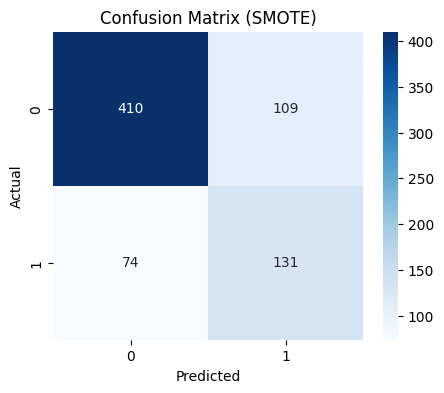

In [ ]:
# Confusion Matrix  Of the GridSearchCV optimized Model

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (SMOTE)")
plt.show()

In [ ]:
# Classification Report of SMOTE optimized Modelling

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.85      0.79      0.82       519
           1       0.55      0.64      0.59       205

    accuracy                           0.75       724
   macro avg       0.70      0.71      0.70       724
weighted avg       0.76      0.75      0.75       724



#### **Final comparison**

In [ ]:

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic + SMOTE",
        "Logistic + GridSearch",
        "Decision Tree",
        "Decision Tree + SMOTE",
        "Random Forest",
        "Random Forest + SMOTE",
        "XGBoost",
        "XGBoost + SMOTE"
    ],
    "Accuracy": [
        acc_log, acc_log_smote, acc_log_grid,
        acc_dt, acc_dt_smote,
        acc_rf, acc_rf_smote,
        acc_xgb, acc_xgb_smote
    ],
    "Precision": [
        prec_log, prec_log_smote, prec_log_grid,
        prec_dt, prec_dt_smote,
        prec_rf, prec_rf_smote,
        prec_xgb, prec_xgb_smote
    ],
    "Recall": [
        rec_log, rec_log_smote, rec_log_grid,
        rec_dt, rec_dt_smote,
        rec_rf, rec_rf_smote,
        rec_xgb, rec_xgb_smote
    ],
    "F1": [
        f1_log, f1_log_smote, f1_log_grid,
        f1_dt, f1_dt_smote,
        f1_rf, f1_rf_smote,
        f1_xgb, f1_xgb_smote
    ]
})

results.sort_values(by="F1", ascending=False)

,Model,Accuracy,Precision,Recall,F1
1,Logistic + SMOTE,0.765193,0.579186,0.624390,0.600939
2,Logistic + GridSearch,0.747238,0.545833,0.639024,0.588764
6,Random Forest + SMOTE,0.761050,0.576923,0.585366,0.581114
5,Random Forest,0.787293,0.675862,0.478049,0.560000
7,XGBoost,0.773481,0.624242,0.502439,0.556757
8,XGBoost + SMOTE,0.755525,0.572165,0.541463,0.556391
0,Logistic Regression,0.787293,0.729730,0.395122,0.512658
4,Decision Tree + SMOTE,0.680939,0.443478,0.497561,0.468966
3,Decision Tree,0.690608,0.454545,0.463415,0.458937


#### **Downloading the best Model**

In [ ]:
# Sort all models from highest to lowest F1 Score
results_sorted = results.sort_values(by="F1", ascending=False)

# Display the sorted model performance
results_sorted


# Get the name of the best-performing model
best_model_name = results_sorted.iloc[0]["Model"]

# Get the F1 Score of the best-performing model
best_f1 = results_sorted.iloc[0]["F1"]

# Display the best model and its F1 Score
print("Best Model:", best_model_name)
print("Best F1 Score:", best_f1)

Best Model: Logistic + SMOTE
Best F1 Score: 0.6009389671361502


In [ ]:
import joblib
from google.colab import files

# Save the best-performing Logistic Regression + SMOTE model
joblib.dump(smote_model, "customer_value_logistic_smote.pkl")

print("Best model saved successfully!")

# Download the saved model
files.download("customer_value_logistic_smote.pkl")

Best model saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>